   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 66.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.

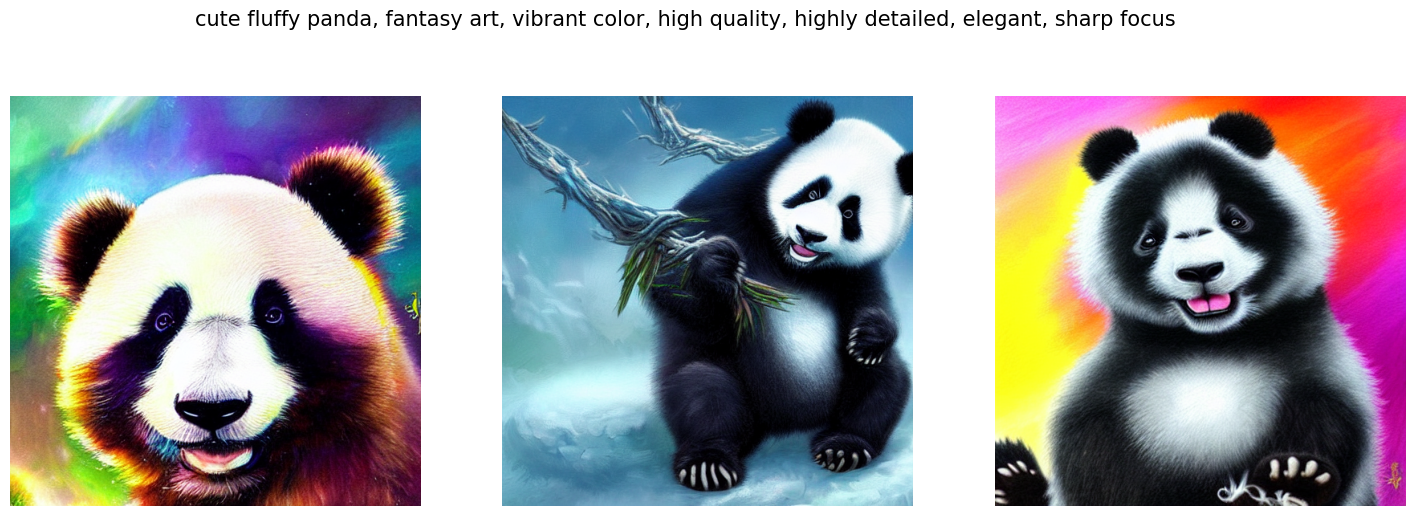

Saved to: /content/stable_diffusion_outputs


array([[[[ 94, 161, 142],
         [ 93, 174, 150],
         [ 90, 179, 147],
         ...,
         [ 58,  49,  84],
         [ 60,  51,  87],
         [ 60,  55,  83]],

        [[ 81, 163, 142],
         [ 82, 171, 147],
         [ 82, 180, 148],
         ...,
         [ 61,  48,  92],
         [ 60,  48,  87],
         [ 61,  50,  82]],

        [[ 88, 180, 153],
         [ 81, 175, 146],
         [ 80, 179, 145],
         ...,
         [ 66,  53, 101],
         [ 62,  49,  93],
         [ 61,  52,  84]],

        ...,

        [[105, 126,  31],
         [147, 180,  66],
         [118, 157,  47],
         ...,
         [ 66,  12,  51],
         [ 84,  25,  62],
         [ 71,  16,  47]],

        [[142, 153,  72],
         [155, 188,  86],
         [165, 195,  67],
         ...,
         [ 70,  11,  52],
         [ 71,  18,  53],
         [ 68,  23,  48]],

        [[143, 153,  91],
         [133, 145,  81],
         [197, 218, 110],
         ...,
         [ 66,  15,  49],
        

In [1]:
!pip -q install -U tensorflow keras-cv

import time
import os
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

print("TensorFlow version:", tf.__version__)
print("KerasCV version:", keras_cv.__version__)

mixed_precision.set_global_policy("mixed_float16")

model = keras_cv.models.StableDiffusion(
    img_width=512,
    img_height=512
)

def plot_images(images, prompt=""):
    plt.figure(figsize=(18, 6))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")
    if prompt:
        plt.suptitle(prompt, fontsize=15)
    plt.show()

def generate_and_save(prompt, batch_size=2, output_dir="/content/stable_diffusion_outputs"):
    os.makedirs(output_dir, exist_ok=True)

    start = time.time()
    images = model.text_to_image(prompt, batch_size=batch_size)
    elapsed = time.time() - start

    print(f"Prompt: {prompt}")
    print(f"Time: {elapsed:.2f} sec")

    plot_images(images, prompt)

    for i, img in enumerate(images):
        filename = os.path.join(output_dir, f"img_{i+1}.png")
        plt.imsave(filename, img)

    print("Saved to:", output_dir)
    return images

# Example
generate_and_save(
    "cute fluffy panda, fantasy art, vibrant color, high quality, highly detailed, elegant, sharp focus",
    batch_size=3
)